# Kaldi vs. ElevenLabs Scribe vs. Whisper -- Benchmark Comparison

Compares `train_kaldi.ipynb`'s Kaldi HMM-GMM model, ElevenLabs Scribe, and
the Whisper small model fine-tuned in `fine-tune-whisper-kaggle.ipynb`, on
the same held-out utterances, using each system's raw `results.csv`
export (`evaluate_kaldi.ipynb` -> `output/kaldi/results.csv`,
`evaluate_elevenlabs.ipynb` -> `output/elevenlabs/results.csv`,
`evaluate_whisper.ipynb` -> `output/whisper/results.csv`). This is the
only notebook that applies text normalization and computes normalized
metrics -- all three eval notebooks export raw metrics only.

**Why the same utterances, not the whole corpus:** ElevenLabs is a
zero-shot pretrained model evaluated on the full corpus; Kaldi and
Whisper are each trained on 80% of speakers (the same speaker-independent
split, seed 42 -- `train_kaldi.ipynb` Section 8 and
`fine-tune-whisper-kaggle.ipynb`'s speaker-independent split) and decoded
only on the held-out 20%. Comparing a trained system's held-out score
against ElevenLabs' whole-corpus score (including utterances the trained
systems saw) would be unfair to neither system in particular, but also
not a real head-to-head. All three systems are restricted here to
Kaldi's exact held-out test set via the shared `corpus_index` column;
ElevenLabs' full-corpus number is also reported separately, clearly
labeled as out-of-scope for the paired comparison. Whisper's own
full-corpus number is *not* reported anywhere in this notebook: unlike
ElevenLabs, Whisper was fine-tuned on 80% of this corpus, so a
full-corpus figure for it would mix train and test data rather than
provide a comparable zero-shot reference point.

**Prerequisite:** `evaluate_kaldi.ipynb`, `evaluate_elevenlabs.ipynb`, and
`evaluate_whisper.ipynb` must each have run at least once. **Environment:**
plain Python -- needs `pandas`, `matplotlib`, `jiwer`.

**Test-set size caveat:** as few as 3 speakers / ~19 utterances in past
runs -- treat this as a qualitative read, not a statistically powered one.


## 1. Load Libraries

In [1]:
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from jiwer import process_words, process_characters

# Fixed per-system colors, reused for every chart -- Kaldi is always this
# blue, ElevenLabs always this orange, Whisper always this green,
# regardless of column order after any groupby/unstack.
SYSTEM_COLORS = {"Kaldi": "#1f77b4", "ElevenLabs": "#ff7f0e", "Whisper": "#2ca02c"}
SYSTEM_ORDER = ["Kaldi", "ElevenLabs", "Whisper"]


def normalize_bisaya(text):
    # The single normalization function for this benchmark -- lowercase,
    # strip punctuation/hyphens, fold u/o together (common Bisaya spelling
    # variation). Used nowhere else in the repo; all eval notebooks
    # export raw text/metrics only.
    text = str(text).lower()
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("-", "")
    text = re.sub(r"[^\w\s]", "", text)
    text = text.replace("u", "o")
    text = re.sub(r"\s+", " ", text).strip()
    return text


## 2. Load All Systems' Results and Match Utterances

Filters ElevenLabs' and Whisper's rows down to the `corpus_index` values
present in Kaldi's results -- Kaldi's held-out test set defines the
matched population.

In [2]:
RESULTS_DIR = Path(os.environ.get("BISAYA_RESULTS_DIR", "../output")).resolve()

KALDI_CSV = RESULTS_DIR / "kaldi" / "results.csv"
ELEVENLABS_CSV = RESULTS_DIR / "elevenlabs" / "results.csv"
WHISPER_CSV = RESULTS_DIR / "whisper" / "results.csv"

assert KALDI_CSV.exists(), f"{KALDI_CSV} not found -- run evaluate_kaldi.ipynb first."
assert ELEVENLABS_CSV.exists(), f"{ELEVENLABS_CSV} not found -- run evaluate_elevenlabs.ipynb first."
assert WHISPER_CSV.exists(), f"{WHISPER_CSV} not found -- run evaluate_whisper.ipynb first."

kaldi_df = pd.read_csv(KALDI_CSV)
elevenlabs_full_df = pd.read_csv(ELEVENLABS_CSV)
whisper_full_df = pd.read_csv(WHISPER_CSV)

matched_ids = set(kaldi_df["corpus_index"])
elevenlabs_df = elevenlabs_full_df[elevenlabs_full_df["corpus_index"].isin(matched_ids)].copy()
whisper_df = whisper_full_df[whisper_full_df["corpus_index"].isin(matched_ids)].copy()

have_all = set(elevenlabs_df["corpus_index"]) & set(whisper_df["corpus_index"])
missing = matched_ids - have_all
if missing:
    print(f"WARNING: {len(missing)} of Kaldi's {len(matched_ids)} test utterances "
          f"have no ElevenLabs and/or Whisper result yet -- comparisons below "
          f"use only the {len(have_all)} utterances all three systems have.")
    kaldi_df = kaldi_df[kaldi_df["corpus_index"].isin(have_all)].copy()
    elevenlabs_df = elevenlabs_df[elevenlabs_df["corpus_index"].isin(have_all)].copy()
    whisper_df = whisper_df[whisper_df["corpus_index"].isin(have_all)].copy()

SYSTEMS = {"Kaldi": kaldi_df, "ElevenLabs": elevenlabs_df, "Whisper": whisper_df}

print(f"Matched utterances: {len(kaldi_df)}")
print(f"Matched speakers:   {kaldi_df['speaker_id'].nunique()}")
print(f"(ElevenLabs full-corpus rows available for context: {len(elevenlabs_full_df)})")


Matched utterances: 19
Matched speakers:   3
(ElevenLabs full-corpus rows available for context: 90)


## 3. Compute Normalized Metrics

Both CSVs carry only raw WER/CER. Normalized WER/CER (and their sub/del/
ins/hits breakdown) are computed here, once, from each row's raw
reference/prediction text via `normalize_bisaya()` -- the only place in
this benchmark normalized metrics are produced.

In [3]:
def add_normalized_metrics(df):
    rows = []
    for _, row in df.iterrows():
        norm_ref = normalize_bisaya(row["reference"])
        norm_pred = normalize_bisaya(row["prediction"])
        wr = process_words(norm_ref, norm_pred)
        cr = process_characters(norm_ref, norm_pred)
        rows.append({
            "id": row["id"],
            "norm_WER": wr.wer, "norm_WER_sub": wr.substitutions,
            "norm_WER_del": wr.deletions, "norm_WER_ins": wr.insertions, "norm_WER_hits": wr.hits,
            "norm_CER": cr.cer, "norm_CER_sub": cr.substitutions,
            "norm_CER_del": cr.deletions, "norm_CER_ins": cr.insertions, "norm_CER_hits": cr.hits,
        })
    return df.merge(pd.DataFrame(rows), on="id", how="left")


for name in SYSTEM_ORDER:
    SYSTEMS[name] = add_normalized_metrics(SYSTEMS[name])
kaldi_df, elevenlabs_df, whisper_df = SYSTEMS["Kaldi"], SYSTEMS["ElevenLabs"], SYSTEMS["Whisper"]


## 4. Headline Comparison Table

- **Pooled**: total edits over total reference words/characters across
  every utterance combined (matches how Kaldi's own `best_wer.sh` reports).
- **Per-utterance mean/median**: per-utterance WER/CER averaged, each
  utterance weighted equally regardless of length.

In [4]:
def pooled_rate(df, sub_col, del_col, ins_col, hits_col):
    sub, dele, ins, hits = df[sub_col].sum(), df[del_col].sum(), df[ins_col].sum(), df[hits_col].sum()
    denom = hits + sub + dele
    return (sub + dele + ins) / denom if denom else float("nan")


rows = []
for metric, prefix in [("WER", "WER"), ("norm_WER", "norm_WER"), ("CER", "CER"), ("norm_CER", "norm_CER")]:
    for system in SYSTEM_ORDER:
        df = SYSTEMS[system]
        rows.append({
            "metric": metric,
            "system": system,
            "pooled": pooled_rate(df, f"{prefix}_sub", f"{prefix}_del", f"{prefix}_ins", f"{prefix}_hits"),
            "mean": df[metric].mean(),
            "median": df[metric].median(),
        })

headline_df = pd.DataFrame(rows).set_index(["metric", "system"])
headline_df.style.format("{:.2%}")


## 5. WER Drill-Down: Raw vs. Normalized

Where the WER improvement from normalization comes from, per system.

In [5]:
breakdown_rows = []
for system in SYSTEM_ORDER:
    df = SYSTEMS[system]
    for stage, prefix in [("Raw", "WER"), ("Normalized", "norm_WER")]:
        sub, dele, ins, hits = (
            df[f"{prefix}_sub"].sum(), df[f"{prefix}_del"].sum(),
            df[f"{prefix}_ins"].sum(), df[f"{prefix}_hits"].sum(),
        )
        breakdown_rows.append({
            "system": system, "stage": stage,
            "substitutions": sub, "deletions": dele, "insertions": ins, "hits": hits,
            "pooled_WER": (sub + dele + ins) / (hits + sub + dele) if (hits + sub + dele) else float("nan"),
        })

breakdown_df = pd.DataFrame(breakdown_rows).set_index(["system", "stage"])
breakdown_df.style.format({"pooled_WER": "{:.2%}"})


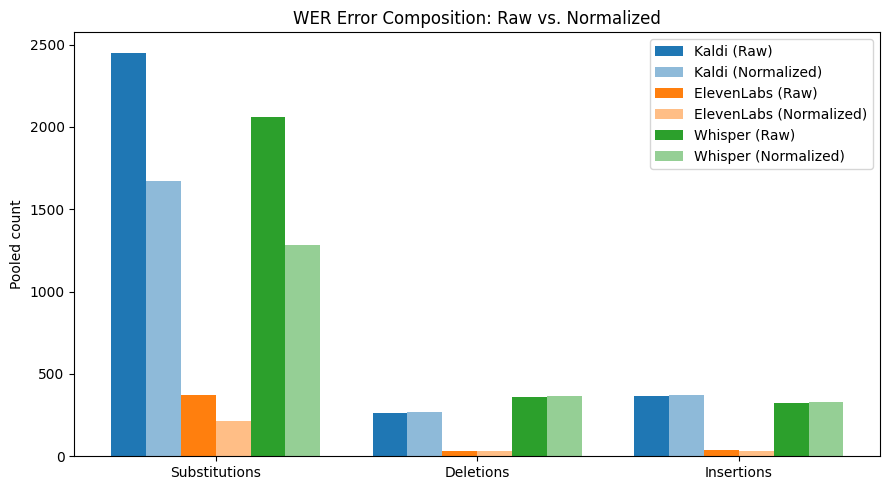

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

error_types = ["substitutions", "deletions", "insertions"]
n_bars = len(SYSTEM_ORDER) * 2  # 2 stages (Raw, Normalized) per system
bar_width = 0.8 / n_bars
x = range(len(error_types))

for i, system in enumerate(SYSTEM_ORDER):
    for j, stage in enumerate(["Raw", "Normalized"]):
        values = [breakdown_df.loc[(system, stage), col] for col in error_types]
        idx = i * 2 + j
        offset = (idx - (n_bars - 1) / 2) * bar_width
        ax.bar(
            [xi + offset for xi in x], values, width=bar_width,
            color=SYSTEM_COLORS[system],
            alpha=1.0 if stage == "Raw" else 0.5,
            label=f"{system} ({stage})",
        )

ax.set_xticks(list(x))
ax.set_xticklabels([e.capitalize() for e in error_types])
ax.set_ylabel("Pooled count")
ax.set_title("WER Error Composition: Raw vs. Normalized")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Word- and Character-Level Confusion Drill-Down

Per-utterance reference/prediction text (raw and normalized), followed by
the most common substitutions/deletions/insertions aggregated across all
utterances -- one table per level (word, character) with both systems'
raw and normalized counts side by side.

### Per-Utterance Reference / Prediction Text

In [7]:
drilldown_rows = []
for system in SYSTEM_ORDER:
    df = SYSTEMS[system]
    for _, row in df.iterrows():
        drilldown_rows.append({
            "system": system,
            "id": row["id"],
            "WER": row["WER"],
            "norm_WER": row["norm_WER"],
            "CER": row["CER"],
            "norm_CER": row["norm_CER"],
            "reference": row["reference"],
            "norm_reference": normalize_bisaya(row["reference"]),
            "prediction": row["prediction"],
            "norm_prediction": normalize_bisaya(row["prediction"]),
        })

drilldown_df = pd.DataFrame(drilldown_rows).sort_values(
    ["system", "WER"], ascending=[True, False]
).reset_index(drop=True)

drilldown_df.head()


,system,id,WER,norm_WER,CER,norm_CER,reference,norm_reference,prediction,norm_prediction
0,ElevenLabs,001_006,0.276596,0.223404,0.071563,0.060665,Kanunay ka ba mag-video call? Dili baya. Ang i...,kanonay ka ba magvideo call dili baya ang impo...,Kanunay ka ba mag-video call? Dili baya. Ang i...,kanonay ka ba magvideo call dili baya ang impo...
1,ElevenLabs,001_004,0.220472,0.157480,0.047486,0.030657,Unsa oras ka kasagaran mubangon? Kasagaran ko ...,onsa oras ka kasagaran mobangon kasagaran ko m...,Unsa oras ka kasagaran mubangon? Kasagaran ko ...,onsa oras ka kasagaran mobangon kasagaran ko m...
2,ElevenLabs,001_007,0.219048,0.180952,0.043548,0.038526,Asa ang imong napanglakwan na? Daghan baya kon...,asa ang imong napanglakwan na daghan baya kong...,Asa ang imong napanglakwan na? Daghan baya kon...,asa ang imong napanglakwan na daghan baya kong...
3,ElevenLabs,001_002,0.185841,0.176991,0.048212,0.043548,Unsa ang imong paborito nga bulak? Daghan kay ...,onsa ang imong paborito nga bolak daghan kay k...,Unsa ang imong paborito nga bulak? Daghan kay ...,onsa ang imong paborito nga bolak daghan kay i...
4,ElevenLabs,001_003,0.155894,0.121673,0.067797,0.058824,Kanus-a nimo labhan ang imong bayo? Ang pasabo...,kanosa nimo labhan ang imong bayo ang pasabot ...,Kanus-a ni molabhan ang imong bayo? Ang pasabo...,kanosa ni molabhan ang imong bayo ang pasabot ...


### Top Word/Character Confusions

In [8]:
def collect_confusions(df, level, normalized):
    process = process_words if level == "word" else process_characters
    subs, dels, inss = Counter(), Counter(), Counter()

    for _, row in df.iterrows():
        ref, hyp = str(row["reference"]), str(row["prediction"])
        if normalized:
            ref, hyp = normalize_bisaya(ref), normalize_bisaya(hyp)

        result = process(ref, hyp)
        for alignment in result.alignments[0]:
            ref_tokens = tuple(result.references[0][alignment.ref_start_idx:alignment.ref_end_idx])
            hyp_tokens = tuple(result.hypotheses[0][alignment.hyp_start_idx:alignment.hyp_end_idx])

            if alignment.type == "substitute":
                if len(ref_tokens) == len(hyp_tokens):
                    for r, h in zip(ref_tokens, hyp_tokens):
                        subs[(r, h)] += 1
                else:
                    subs[(" ".join(ref_tokens), " ".join(hyp_tokens))] += 1
            elif alignment.type == "delete":
                for r in ref_tokens:
                    dels[r] += 1
            elif alignment.type == "insert":
                for h in hyp_tokens:
                    inss[h] += 1

    return subs, dels, inss


def confusion_table(level, top_n=10):
    raw_counts = {system: collect_confusions(SYSTEMS[system], level, False) for system in SYSTEM_ORDER}
    norm_counts = {system: collect_confusions(SYSTEMS[system], level, True) for system in SYSTEM_ORDER}
    kind_index = {"sub": 0, "del": 1, "ins": 2}

    blocks = []
    for kind, label in [("sub", "SUB"), ("del", "DEL"), ("ins", "INS")]:
        idx = kind_index[kind]
        items = set()
        for system in SYSTEM_ORDER:
            items |= set(raw_counts[system][idx])
            items |= set(norm_counts[system][idx])

        block_rows = []
        for item in items:
            if kind == "sub":
                reference, prediction = item
            elif kind == "del":
                reference, prediction = item, ""
            else:
                reference, prediction = "", item

            norm_reference = normalize_bisaya(reference) if reference else ""
            norm_prediction = normalize_bisaya(prediction) if prediction else ""

            row = {
                "type": label,
                "reference": reference,
                "prediction": prediction,
                "norm_reference": norm_reference,
                "norm_prediction": norm_prediction,
            }
            if kind == "sub":
                row["resolved_by_norm"] = norm_reference == norm_prediction

            total = 0
            for system in SYSTEM_ORDER:
                c_raw = raw_counts[system][idx].get(item, 0)
                c_norm = norm_counts[system][idx].get(item, 0)
                row[f"{system}_count_raw"] = c_raw
                row[f"{system}_count_norm"] = c_norm
                total += c_raw + c_norm
            row["total"] = total
            block_rows.append(row)

        block_df = pd.DataFrame(block_rows).sort_values("total", ascending=False).head(top_n)
        blocks.append(block_df)

    return pd.concat(blocks, ignore_index=True)


word_confusion_df = confusion_table("word")
char_confusion_df = confusion_table("char")

print("=== Word-level confusions (top 10 per type) ===")
display(word_confusion_df)


=== Word-level confusions (top 10 per type) ===


,type,reference,prediction,norm_reference,norm_prediction,resolved_by_norm,Kaldi_count_raw,Kaldi_count_norm,ElevenLabs_count_raw,ElevenLabs_count_norm,Whisper_count_raw,Whisper_count_norm,total
0,SUB,ug,og,og,og,True,34,0,13,0,73,0,120
1,SUB,og,ug,og,og,True,33,0,43,0,37,0,113
2,SUB,nga,na,nga,na,False,20,20,2,2,8,8,60
3,SUB,Sa,sa,sa,sa,True,23,0,0,0,7,0,30
4,SUB,o,og,o,og,False,4,10,0,0,4,6,24
5,SUB,Ang,ang,ang,ang,True,19,0,1,0,4,0,24
6,SUB,pagkatolog,pangkatolog,pagkatolog,pangkatolog,False,0,21,0,0,0,0,21
7,SUB,kon,kong,kon,kong,False,1,8,0,3,1,7,20
8,SUB,nako,ako,nako,ako,False,4,4,1,1,4,5,19
9,SUB,kaayo,kayo,kaayo,kayo,False,0,0,0,0,9,10,19


In [9]:
print("=== Character-level confusions (top 10 per type) ===")
display(char_confusion_df)


=== Character-level confusions (top 10 per type) ===


,type,reference,prediction,norm_reference,norm_prediction,resolved_by_norm,Kaldi_count_raw,Kaldi_count_norm,ElevenLabs_count_raw,ElevenLabs_count_norm,Whisper_count_raw,Whisper_count_norm,total
0,SUB,o,a,o,a,False,122,171,2,4,23,30,352
1,SUB,o,u,o,o,True,93,0,57,0,169,0,319
2,SUB,u,o,o,o,True,94,0,25,0,190,0,309
3,SUB,e,i,e,i,False,30,33,2,2,62,68,197
4,SUB,m,n,m,n,False,59,60,3,3,7,6,138
5,SUB,y,i,y,i,False,23,24,1,1,40,40,129
6,SUB,l,n,l,n,False,56,61,0,0,3,2,122
7,SUB,i,a,i,a,False,40,38,1,1,11,10,101
8,SUB,e,a,e,a,False,48,44,1,1,3,3,100
9,SUB,i,e,i,e,False,19,19,5,5,26,26,100


## 7. Side-by-Side Charts

Chosen for a small, paired test set: (1) headline rates, (2) which system
wins each utterance, (3) per-speaker rates for shared speakers, (4)
win-rate summary.

Win rate (lower WER): Kaldi 0, ElevenLabs 19, Whisper 0, ties 0 (of 19 matched utterances)


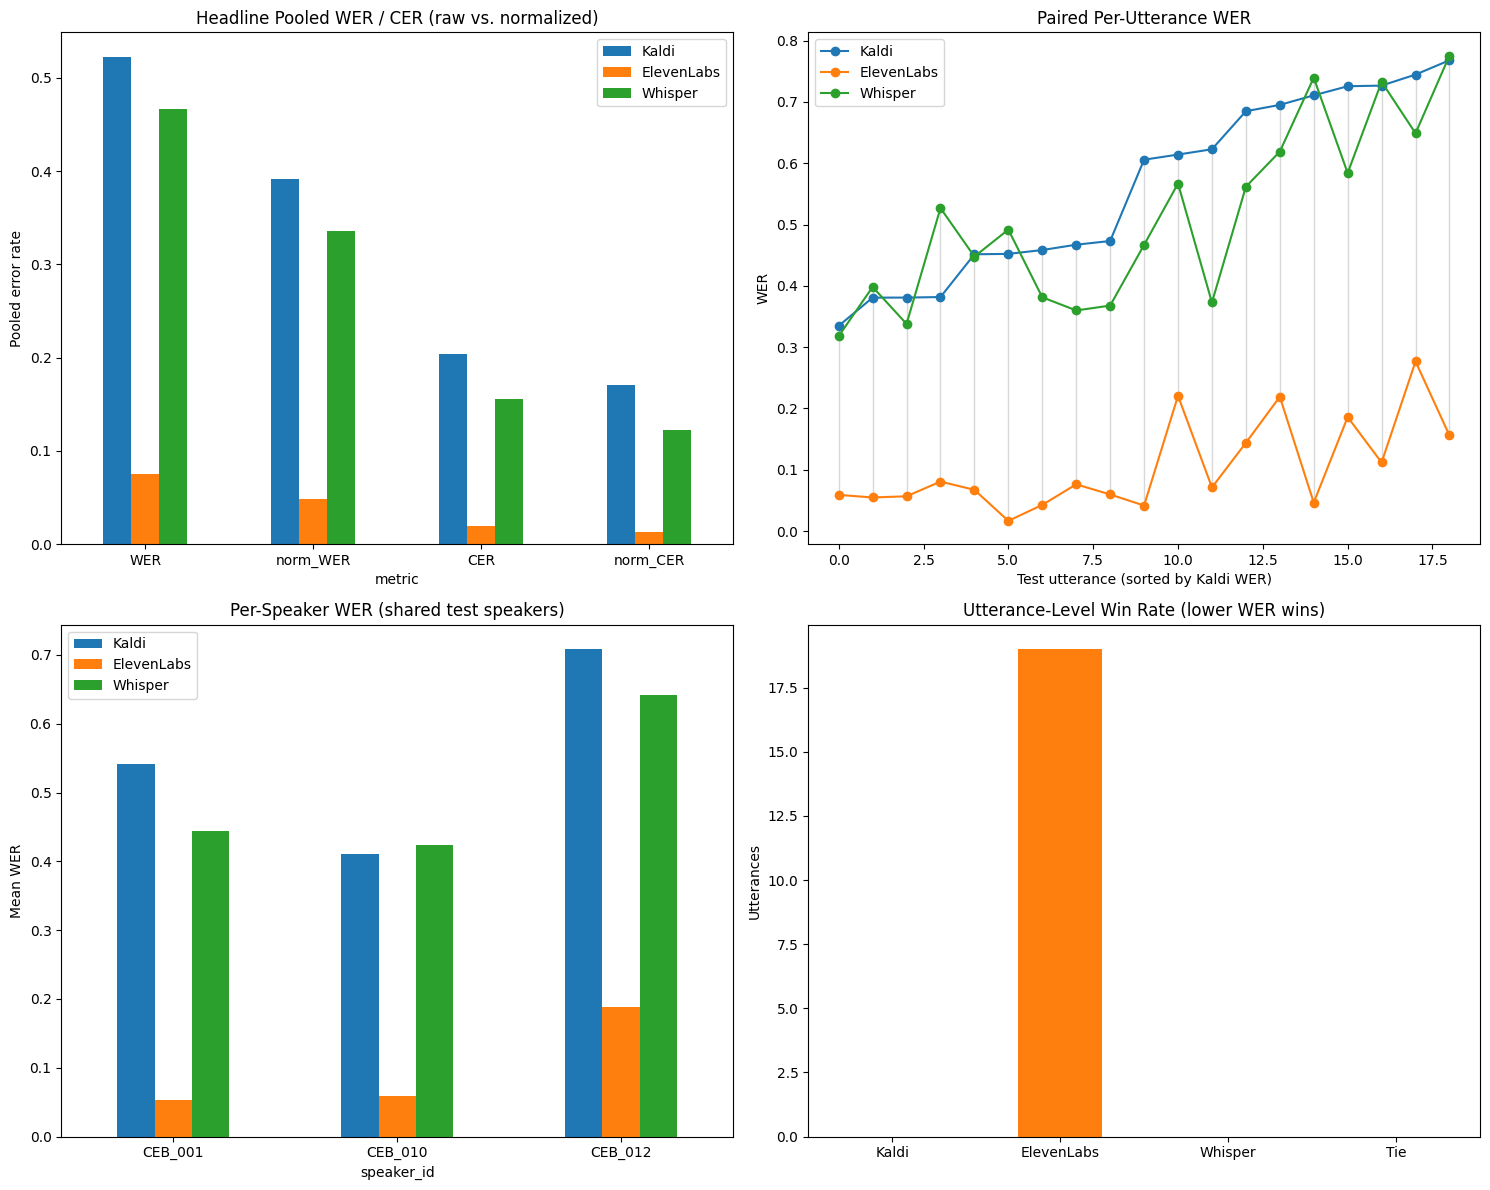

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

plot_metrics = ["WER", "norm_WER", "CER", "norm_CER"]
pooled_wide = headline_df["pooled"].unstack("system")[SYSTEM_ORDER].loc[plot_metrics]
pooled_wide.plot(kind="bar", ax=axes[0, 0], color=[SYSTEM_COLORS[s] for s in SYSTEM_ORDER])
axes[0, 0].set_ylabel("Pooled error rate")
axes[0, 0].set_title("Headline Pooled WER / CER (raw vs. normalized)")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(title=None)

paired = SYSTEMS[SYSTEM_ORDER[0]][["id", "corpus_index", "WER"]].rename(columns={"WER": SYSTEM_ORDER[0]})
for system in SYSTEM_ORDER[1:]:
    paired = paired.merge(
        SYSTEMS[system][["corpus_index", "WER"]].rename(columns={"WER": system}),
        on="corpus_index",
    )
paired = paired.sort_values(SYSTEM_ORDER[0]).reset_index(drop=True)

x = range(len(paired))
for system in SYSTEM_ORDER:
    axes[0, 1].plot(x, paired[system], marker="o", color=SYSTEM_COLORS[system], label=system)
for i in x:
    vals = [paired[system][i] for system in SYSTEM_ORDER]
    axes[0, 1].plot(
        [i, i], [min(vals), max(vals)],
        color="gray", alpha=0.3, linewidth=1, zorder=0,
    )
axes[0, 1].set_xlabel(f"Test utterance (sorted by {SYSTEM_ORDER[0]} WER)")
axes[0, 1].set_ylabel("WER")
axes[0, 1].set_title("Paired Per-Utterance WER")
axes[0, 1].legend()


def _row_winner(row):
    vals = {system: row[system] for system in SYSTEM_ORDER}
    best = min(vals.values())
    winners = [s for s, v in vals.items() if v == best]
    return winners[0] if len(winners) == 1 else "Tie"


paired["winner"] = paired.apply(_row_winner, axis=1)
winner_counts = paired["winner"].value_counts()
win_counts = pd.Series({s: winner_counts.get(s, 0) for s in SYSTEM_ORDER + ["Tie"]})
print("Win rate (lower WER): " + ", ".join(f"{s} {win_counts[s]}" for s in SYSTEM_ORDER) +
      f", ties {win_counts['Tie']} (of {len(paired)} matched utterances)")

speaker_wer = pd.DataFrame({
    system: SYSTEMS[system].groupby("speaker_id")["WER"].mean() for system in SYSTEM_ORDER
})[SYSTEM_ORDER]
speaker_wer.plot(kind="bar", ax=axes[1, 0], color=[SYSTEM_COLORS[s] for s in SYSTEM_ORDER])
axes[1, 0].set_ylabel("Mean WER")
axes[1, 0].set_title("Per-Speaker WER (shared test speakers)")
axes[1, 0].tick_params(axis="x", rotation=0)

win_colors = [SYSTEM_COLORS[s] for s in SYSTEM_ORDER] + ["#888888"]
win_counts.plot(kind="bar", ax=axes[1, 1], color=win_colors)
axes[1, 1].set_ylabel("Utterances")
axes[1, 1].set_title("Utterance-Level Win Rate (lower WER wins)")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [11]:
num_cols = ['WER','norm_WER', 'CER', 'norm_CER',
       'WER_sub', 'WER_del', 'WER_ins', 'WER_hits',  'CER_sub',
       'CER_del', 'CER_ins', 'CER_hits', 'norm_WER_sub',
       'norm_WER_del', 'norm_WER_ins', 'norm_WER_hits',
       'norm_CER_sub', 'norm_CER_del', 'norm_CER_ins', 'norm_CER_hits']

side_df = pd.concat([SYSTEMS[system][num_cols].mean() for system in SYSTEM_ORDER], axis=1)
side_df.columns = SYSTEM_ORDER

side_df

,Kaldi,ElevenLabs,Whisper
WER,0.562070,0.104496,0.510410
norm_WER,0.434002,0.074260,0.380600
CER,0.235301,0.027372,0.162771
norm_CER,0.199747,0.020524,0.126681
WER_sub,129.052632,19.736842,108.578947
WER_del,13.736842,1.789474,19.052632
WER_ins,19.368421,1.894737,17.157895
WER_hits,167.421053,288.684211,182.578947
CER_sub,181.263158,12.052632,79.473684
CER_del,123.631579,10.631579,108.052632
